# Lab 3 — Detección de anomalías con Machine Learning

**Estudiante:** Yana  
**Curso:** Seguridad Informática  
**Modelo:** Isolation Forest

El dataset se lee desde `lab3/network_traffic.csv`. La columna `label` se usa solo para validación, no para entrenamiento.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

BASE_DIR = Path.cwd()
if BASE_DIR.name != 'lab3':
    DATA_PATH = BASE_DIR / 'lab3' / 'network_traffic.csv'
    MODEL_PATH = BASE_DIR / 'lab3' / 'modelo_anomalias.pkl'
else:
    DATA_PATH = BASE_DIR / 'network_traffic.csv'
    MODEL_PATH = BASE_DIR / 'modelo_anomalias.pkl'

print('Dataset:', DATA_PATH)

Dataset: /home/ubuntu/examen-practico-yana/lab3/network_traffic.csv


## 3.1 Exploración y preprocesamiento

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

print("\nPrimeras filas:")
display(df.head())

print("\nEstadísticas descriptivas:")
display(df.describe(include="all"))

print("\nValores nulos por columna:")
print(df.isna().sum())

Dimensiones: 10000 filas x 10 columnas

Primeras filas:


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
0,2026-06-29 17:49:49,10.0.1.210,192.138.43.20,993,UDP,17809,285793,449.97,774,normal
1,2026-06-04 08:42:32,10.0.4.236,34.48.200.50,993,ICMP,399809,768327,249.29,31,normal
2,2026-06-28 13:34:54,10.0.3.52,8.135.241.97,123,UDP,169826,445904,307.46,48,normal
3,2026-06-14 06:06:27,10.0.4.63,104.8.254.187,993,ICMP,213134,588347,167.21,583,normal
4,2026-06-18 21:57:23,10.0.1.115,52.244.55.165,53,UDP,374745,113665,271.42,1184,normal



Estadísticas descriptivas:


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
count,10000,10000,10000,10000.000000,10000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000
unique,9984,1522,9999,NaN,3,NaN,NaN,NaN,NaN,2
top,2026-06-26 18:59:33,10.0.1.120,172.188.88.234,NaN,TCP,NaN,NaN,NaN,NaN,normal
freq,2,15,2,NaN,3490,NaN,NaN,NaN,NaN,9465
mean,NaN,NaN,NaN,951.276700,NaN,3.342492e+07,471127.126300,286.431978,1527.035100,NaN
std,NaN,NaN,NaN,1478.787872,NaN,1.592298e+08,297970.994368,181.614151,3824.909285,NaN
min,NaN,NaN,NaN,22.000000,NaN,1.270000e+02,131.000000,0.130000,1.000000,NaN
25%,NaN,NaN,NaN,80.000000,NaN,1.316565e+05,207127.500000,124.265000,380.000000,NaN
50%,NaN,NaN,NaN,443.000000,NaN,2.630335e+05,468074.500000,287.940000,785.000000,NaN
75%,NaN,NaN,NaN,993.000000,NaN,3.954645e+05,724220.250000,443.512500,1188.000000,NaN



Valores nulos por columna:
timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64


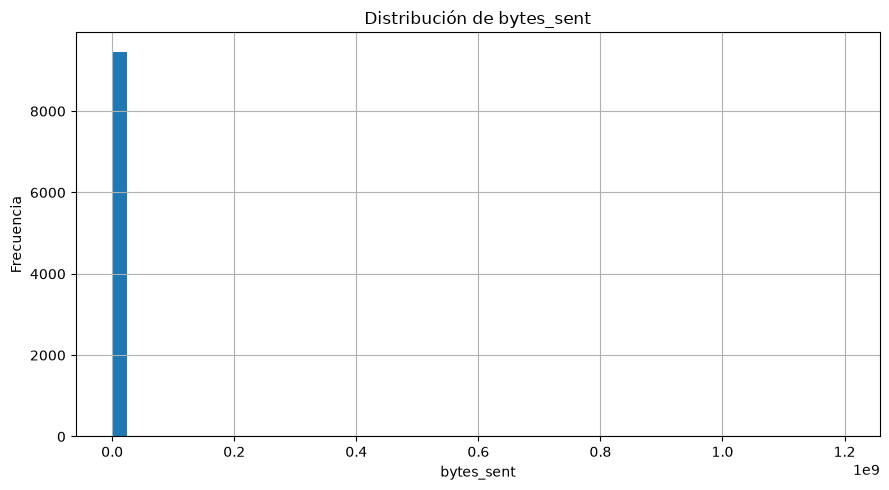

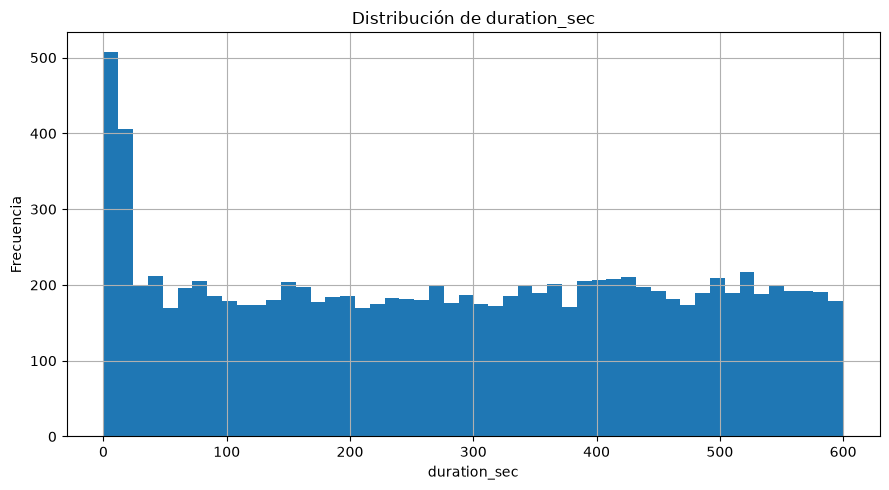

In [3]:
# Histogramas solicitados: bytes_sent y duration_sec
plt.figure(figsize=(9,5))
df['bytes_sent'].hist(bins=50)
plt.title('Distribución de bytes_sent')
plt.xlabel('bytes_sent')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
df['duration_sec'].hist(bins=50)
plt.title('Distribución de duration_sec')
plt.xlabel('duration_sec')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [4]:
# Copia de trabajo y conversiones
work = df.copy()
work['timestamp'] = pd.to_datetime(work['timestamp'], errors='coerce')

numeric_base = ['dst_port', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets']
for col in numeric_base:
    work[col] = pd.to_numeric(work[col], errors='coerce')
    work[col] = work[col].fillna(work[col].median())

# Tratamiento de atípicos extremos: clipping entre percentiles 1 y 99
clip_bounds = {}
for col in numeric_base:
    q01, q99 = work[col].quantile([0.01, 0.99])
    clip_bounds[col] = (float(q01), float(q99))
    work[col] = work[col].clip(q01, q99)

# Feature engineering solicitado
work['hour'] = work['timestamp'].dt.hour.fillna(0)
work['dayofweek'] = work['timestamp'].dt.dayofweek.fillna(0)
work['ratio_bytes'] = work['bytes_sent'] / (work['bytes_recv'] + 1)
work['bytes_por_segundo'] = (work['bytes_sent'] + work['bytes_recv']) / (work['duration_sec'] + 1)
work['packets_por_segundo'] = work['packets'] / (work['duration_sec'] + 1)

protocol_dummies = pd.get_dummies(work['protocol'].fillna('UNKNOWN'), prefix='protocol')
features = pd.concat([
    work[['dst_port','bytes_sent','bytes_recv','duration_sec','packets','hour','dayofweek','ratio_bytes','bytes_por_segundo','packets_por_segundo']],
    protocol_dummies
], axis=1)

features = features.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print('Features usadas para entrenamiento:', list(features.columns))
print('Matriz normalizada:', X_scaled.shape)

Features usadas para entrenamiento: ['dst_port', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'hour', 'dayofweek', 'ratio_bytes', 'bytes_por_segundo', 'packets_por_segundo', 'protocol_ICMP', 'protocol_TCP', 'protocol_UDP']
Matriz normalizada: (10000, 13)


## 3.2 Entrenamiento del modelo y métricas

Precision: 1.0000
Recall:    0.9346
F1-Score:  0.9662

Reporte de clasificación:
              precision    recall  f1-score   support

     anomaly       1.00      0.93      0.97       535
      normal       1.00      1.00      1.00      9465

    accuracy                           1.00     10000
   macro avg       1.00      0.97      0.98     10000
weighted avg       1.00      1.00      1.00     10000



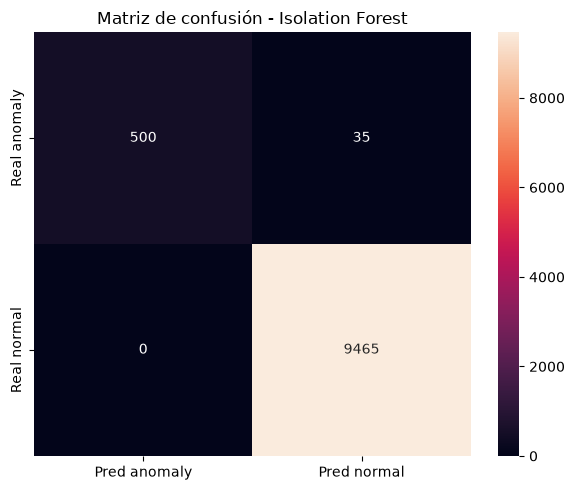

In [5]:
# Entrenamiento sin usar label
model = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
model.fit(X_scaled)

pred = model.predict(X_scaled)  # -1 = anomalía, 1 = normal

# Validación con label solo después del entrenamiento
label_map = {'anomaly': -1, 'normal': 1, 'anomalia': -1}
y_true = work['label'].astype(str).str.lower().map(label_map)
if y_true.isna().any():
    print('Advertencia: existen labels no reconocidos. Valores:', work['label'].unique())
    y_true = y_true.fillna(1)
y_true = y_true.astype(int)

precision = precision_score(y_true, pred, pos_label=-1, zero_division=0)
recall = recall_score(y_true, pred, pos_label=-1, zero_division=0)
f1 = f1_score(y_true, pred, pos_label=-1, zero_division=0)

print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_true, pred, labels=[-1,1], target_names=['anomaly','normal'], zero_division=0))

cm = confusion_matrix(y_true, pred, labels=[-1, 1])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Pred anomaly','Pred normal'], yticklabels=['Real anomaly','Real normal'])
plt.title('Matriz de confusión - Isolation Forest')
plt.tight_layout()
plt.show()

## 3.3 Interpretación y umbral dinámico

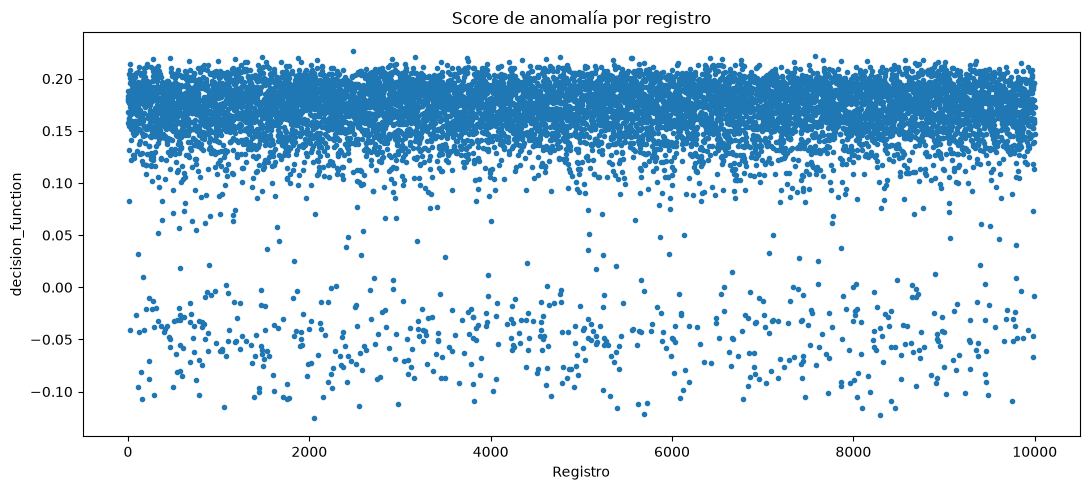

In [6]:
scores = model.decision_function(X_scaled)
work['score_anomalia'] = scores
work['prediccion_base'] = pred

plt.figure(figsize=(11,5))
plt.plot(scores, marker='.', linewidth=0)
plt.title('Score de anomalía por registro')
plt.xlabel('Registro')
plt.ylabel('decision_function')
plt.tight_layout()
plt.show()

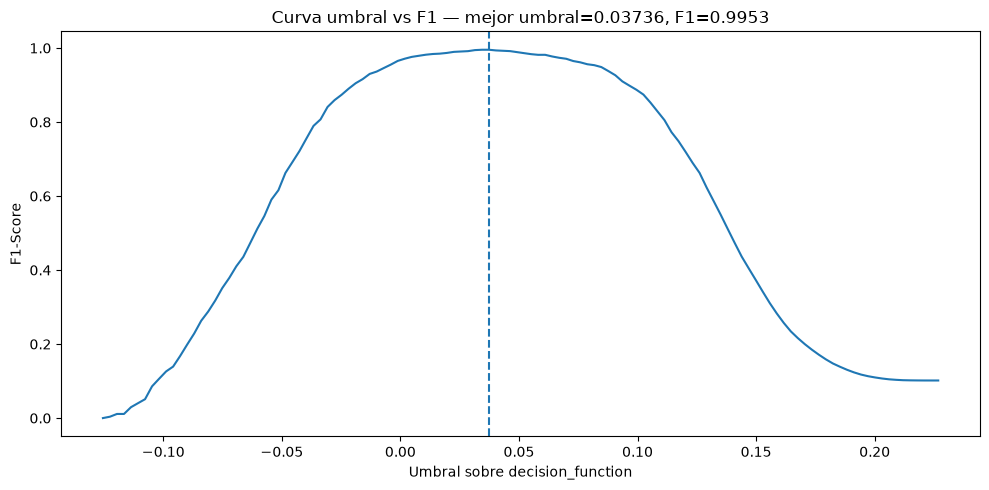

Mejor umbral: 0.0373617582332095
Mejor F1: 0.9953314659197012


In [7]:
thresholds = np.linspace(scores.min(), scores.max(), 120)
f1_values = []
for th in thresholds:
    pred_th = np.where(scores < th, -1, 1)
    f1_values.append(f1_score(y_true, pred_th, pos_label=-1, zero_division=0))

best_idx = int(np.argmax(f1_values))
best_threshold = float(thresholds[best_idx])
best_f1 = float(f1_values[best_idx])

plt.figure(figsize=(10,5))
plt.plot(thresholds, f1_values)
plt.axvline(best_threshold, linestyle='--')
plt.title(f'Curva umbral vs F1 — mejor umbral={best_threshold:.5f}, F1={best_f1:.4f}')
plt.xlabel('Umbral sobre decision_function')
plt.ylabel('F1-Score')
plt.tight_layout()
plt.show()

print('Mejor umbral:', best_threshold)
print('Mejor F1:', best_f1)

In [8]:
cols_mostrar = list(df.columns) + ['score_anomalia', 'prediccion_base']
top10_anomalias = work.sort_values('score_anomalia').head(10)[cols_mostrar]
display(top10_anomalias)

,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label,score_anomalia,prediccion_base
2050,2026-06-03 01:08:51,10.0.1.32,34.172.187.86,3389,TCP,8.984671e+08,5762.93,2.5397,21611.00,anomaly,-0.125436,-1
8291,2026-06-28 17:24:00,10.0.4.238,52.41.253.59,4444,TCP,9.677565e+08,7717.00,2.5397,21744.00,anomaly,-0.122446,-1
5693,2026-06-09 14:26:18,10.0.3.206,34.116.198.29,8080,TCP,9.480389e+08,6427.00,3.5800,22150.00,anomaly,-0.121352,-1
5396,2026-06-08 17:42:53,10.0.1.24,52.87.59.24,22,UDP,6.693261e+08,5762.93,3.2100,24398.68,anomaly,-0.115877,-1
8458,2026-06-29 15:05:30,10.0.3.44,34.123.35.182,23,TCP,4.979570e+08,6455.00,2.5397,24398.68,anomaly,-0.115772,-1
8091,2026-06-01 15:20:20,10.0.1.186,34.217.209.140,8080,TCP,9.677565e+08,14429.00,2.5397,13937.00,anomaly,-0.115371,-1
1056,2026-06-16 03:29:46,10.0.1.69,192.6.221.164,3389,TCP,9.677565e+08,14736.00,2.5397,20946.00,anomaly,-0.114762,-1
2548,2026-06-12 03:17:21,10.0.0.83,203.245.254.237,3389,TCP,9.429476e+08,8316.00,2.5397,18346.00,anomaly,-0.114257,-1
5622,2026-06-14 22:10:20,10.0.1.205,52.32.136.183,8080,TCP,7.047601e+08,8288.00,4.5700,22376.00,anomaly,-0.112347,-1
2977,2026-06-26 21:12:59,10.0.5.179,52.107.19.141,4444,UDP,9.677565e+08,19446.00,2.5397,24398.68,anomaly,-0.111844,-1


### Interpretación de posibles amenazas

Los registros con menor `score_anomalia` pueden representar amenaza cuando muestran bytes enviados muy altos, tasas elevadas de transferencia, puertos inusuales o patrones fuera de lo normal.

## 3.4 Exportación del modelo

In [9]:
paquete_modelo = {
    'model': model,
    'scaler': scaler,
    'feature_columns': list(features.columns),
    'threshold': best_threshold,
    'clip_bounds': clip_bounds,
    'nota': 'Modelo Isolation Forest para detección de anomalías. -1=anomalia, 1=normal.'
}
joblib.dump(paquete_modelo, MODEL_PATH)
print('Modelo guardado en:', MODEL_PATH)

Modelo guardado en: /home/ubuntu/examen-practico-yana/lab3/modelo_anomalias.pkl


## Prueba del script `predecir.py`

Desde terminal:

```bash
cd examen-practico-yana
source .venv/bin/activate
python lab3/predecir.py lab3/nuevo_trafico.csv
```